In [22]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "loan_approval_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohitgrewal/loan-approval-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1446/2137810140.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'loan-approval-dataset' dataset.
First 5 records:    loan_id  no_of_dependents      education  self_employed   income_annum  \
0        1                 2       Graduate             No        9600000   
1        2                 0   Not Graduate            Yes        4100000   
2        3                 3       Graduate             No        9100000   
3        4                 3       Graduate             No        8200000   
4        5                 5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commerc

In [23]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [24]:
#define input features
X=df[["no_of_dependents", "education", "self_employed", "income_annum", "loan_amount", "loan_term", "cibil_score","residential_assets_value", "commercial_assets_value", "luxury_assets_value", "bank_asset_value" ]]
#define target that we want to predict
y = df["loan_status"]

#X is the info we are giving to the model to learn from (features) and y is what we want it to predict = approved/rejected
#leave out loan_id because its a useless number

In [25]:
print(X.head())

   no_of_dependents      education self_employed  income_annum  loan_amount  \
0                 2       Graduate            No       9600000     29900000   
1                 0   Not Graduate           Yes       4100000     12200000   
2                 3       Graduate            No       9100000     29700000   
3                 3       Graduate            No       8200000     30700000   
4                 5   Not Graduate           Yes       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  
0

In [26]:
#encode education and self employed category to turn them into integers
import pandas as pd
X_encoded = pd.get_dummies(X, dtype = int)
X_encoded

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,0,1,0
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,1,0,1
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,0,1,0
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,0,1,0
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1000000,2300000,12,317,2800000,500000,3300000,800000,1,0,0,1
4265,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0,1,0,1
4266,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,1,1,0
4267,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,0,1,1,0


In [27]:
print(X_encoded.head())

   no_of_dependents  income_annum  loan_amount  loan_term  cibil_score  \
0                 2       9600000     29900000         12          778   
1                 0       4100000     12200000          8          417   
2                 3       9100000     29700000         20          506   
3                 3       8200000     30700000          8          467   
4                 5       9800000     24200000         20          382   

   residential_assets_value  commercial_assets_value  luxury_assets_value  \
0                   2400000                 17600000             22700000   
1                   2700000                  2200000              8800000   
2                   7100000                  4500000             33300000   
3                  18200000                  3300000             23300000   
4                  12400000                  8200000             29400000   

   bank_asset_value  education_ Graduate  education_ Not Graduate  \
0           8000000    

In [28]:
#now we divide the data into an 80:20 split for training and testing so the model can learn from this
from sklearn.model_selection import train_test_split

#train/test split as before (same random state ensures identical splits)
train_X, test_X, train_y, test_y = train_test_split(X_encoded, y, test_size=0.2, random_state=1) #here the test size means we test 20% and therefore implies we train 80% e.g. out of 4269 rows 3415 go to training and 854 to testing
#random split = 1 just means data is split same way = which specific rows end up in each split remains the same = same shuffle

In [29]:
print(train_y.value_counts())

loan_status
Approved    2135
Rejected    1280
Name: count, dtype: int64


In [30]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators = 300, #no.of trees
    max_depth=4, #how deep each tree can grow
    min_samples_leaf=10, #minimum rows needed at each leaf
    max_features="sqrt", #features considered at each split = at each split it considers the square root of total number of features. in this case we have 13 so it will consider roughly 3-4 features
    #random forest made of of many decision trees and at each point where a tree makes a split/decision it doesnt look at all features it only considers a random subset of them
    class_weight="balanced", #accounts for our imbalanced data
    random_state=1, #reproducible results
    n_jobs=-1 #use all available CPU cores
)

model.fit(train_X, train_y)
print("Random Forest fitted!")
print(f"Number of trees: {model.n_estimators}")

Random Forest fitted!
Number of trees: 300


In [31]:
#evaluation metrics
from sklearn.metrics import classification_report, balanced_accuracy_score

pred_y = model.predict(test_X)

print(classification_report(
    test_y, pred_y,
    target_names = ["Approval", "Rejection"]
))

              precision    recall  f1-score   support

    Approval       1.00      0.92      0.96       521
   Rejection       0.89      0.99      0.94       333

    accuracy                           0.95       854
   macro avg       0.94      0.96      0.95       854
weighted avg       0.95      0.95      0.95       854



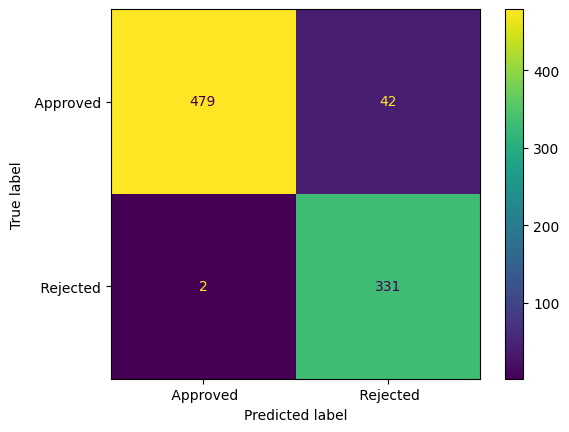

In [32]:
#confusion matrix = breaks down correct and incorrect predictions for each class
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = model.predict(test_X) #use model to make predictions on data


cm = confusion_matrix(test_y, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot()
plt.show()

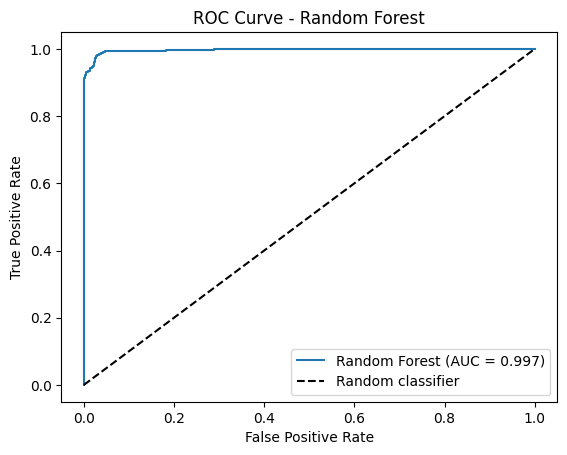

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score


rf_pred_prob = model.predict_proba(test_X)[:, 1]
rf_y_binary = (test_y == ' Rejected').astype(int)

rf_fpr, rf_tpr, _ = roc_curve(rf_y_binary, rf_pred_prob)
rf_auc = roc_auc_score(rf_y_binary, rf_pred_prob)

plt.figure()
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

In [34]:
#Random forest has inbuilt feature of importance scores = understands usefulness of each feature for making predictions = we can identify most influential features

#get feature importances
importances = model.feature_importances_
importances

#spits out array of numbers that adds up to 1 where each number shows how much that feature contributed to decisions across all 300 trees

array([3.69023703e-03, 1.15074125e-02, 2.15869662e-02, 9.24994099e-02,
       8.16705020e-01, 1.18769366e-02, 1.46671738e-02, 1.19630253e-02,
       1.04926225e-02, 1.30638154e-03, 1.18583934e-03, 1.73679306e-03,
       7.82182611e-04])

In [35]:
#attaching column names to each number so we can actually understand what they mean

feature_importance = pd.Series(model.feature_importances_, index=X_encoded.columns)
feature_importance

,0
no_of_dependents,0.003690
income_annum,0.011507
loan_amount,0.021587
loan_term,0.092499
cibil_score,0.816705
residential_assets_value,0.011877
commercial_assets_value,0.014667
luxury_assets_value,0.011963
bank_asset_value,0.010493
education_ Graduate,0.001306


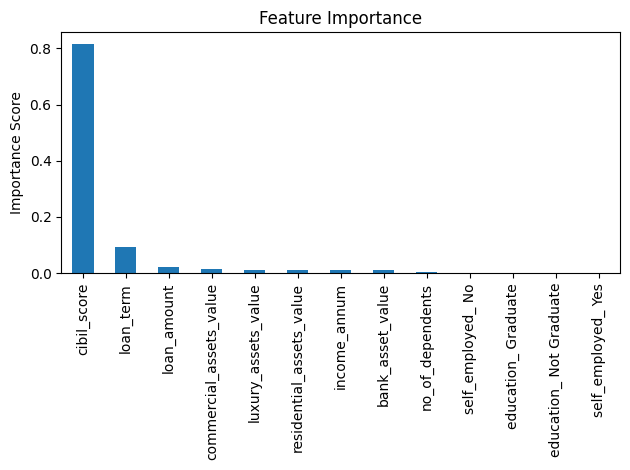

In [36]:
feature_importance.sort_values(ascending = False).plot(kind="bar")
#sorting features from highest to lowest so most important feature appears first on left
#of bar chart

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [37]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "max_depth": [2,4,6],
    "min_samples_leaf": [5,10,20],
    "n_estimators": [100,200,300]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5, #5 fold cross validation
    scoring = "accuracy", #metric for optimisation
    n_jobs=-1, #use all CPU cores
    verbose=1 #prints progress as runs
)

grid_search.fit(train_X, train_y)

best_model = grid_search.best_estimator_
predictions_tuned = best_model.predict(test_X)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 300}
Best score: 0.9613469985358712


In [ ]:
#max depth went from 4->6, min samples leaf went from 10->5 = leaves can be based on smaller samples and number of trees stayed same at 300

#min_samples_leaf = sayes each leaf must contain at least X rows of data (e.g. 10 individuals in our case)
#tree wont make a final decision based on fewer than 10 peoples data
#if a leaf had only 2 people and both happened to get rejected it may conclude everyone in this situation gets rejected but based on almost no evidence = overfitting
#basically 'dont make conclusions from small samples'

In [38]:
print("Original model:")
print(classification_report(test_y, predictions))

print("Tuned model:")
print(classification_report(test_y, predictions_tuned))

Original model:
              precision    recall  f1-score   support

    Approved       1.00      0.92      0.96       521
    Rejected       0.89      0.99      0.94       333

    accuracy                           0.95       854
   macro avg       0.94      0.96      0.95       854
weighted avg       0.95      0.95      0.95       854

Tuned model:
              precision    recall  f1-score   support

    Approved       1.00      0.94      0.97       521
    Rejected       0.91      0.99      0.95       333

    accuracy                           0.96       854
   macro avg       0.96      0.97      0.96       854
weighted avg       0.96      0.96      0.96       854



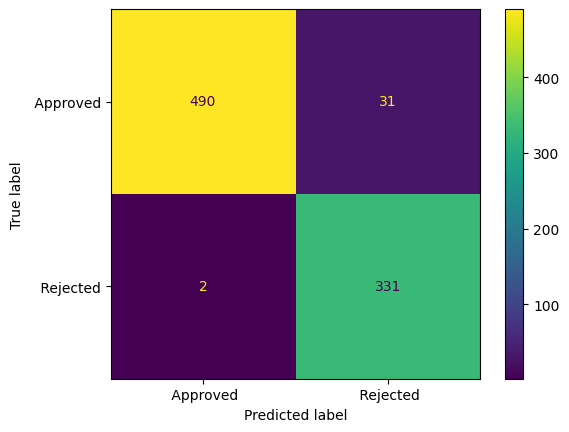

In [39]:
#confusion matrix post tuning

#confusion matrix = breaks down correct and incorrect predictions for each class

predictions = model.predict(test_X) #use model to make predictions on data


cm = confusion_matrix(test_y, predictions_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [40]:
#tuned AUC score improvement

rf_pred_prob_tuned = best_model.predict_proba(test_X)[:, 1]
rf_y_binary = (test_y.str.strip() == 'Rejected').astype(int)

rf_fpr_tuned, rf_tpr_tuned, _ = roc_curve(rf_y_binary, rf_pred_prob_tuned)
rf_auc_tuned = roc_auc_score(rf_y_binary, rf_pred_prob_tuned)

print(f"Original AUC: 0.997")
print(f"Tuned AUC: {rf_auc_tuned:.3f}")

Original AUC: 0.997
Tuned AUC: 0.998


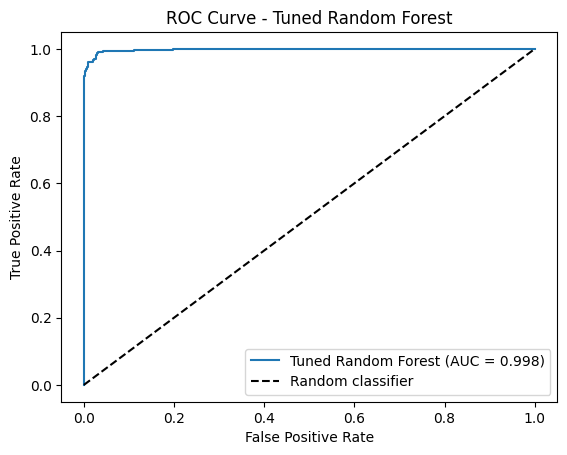

In [41]:
#tuned ROC curve

rf_pred_prob_tuned = best_model.predict_proba(test_X)[:, 1]
rf_y_binary = (test_y.str.strip() == 'Rejected').astype(int)

rf_fpr_tuned, rf_tpr_tuned, _ = roc_curve(rf_y_binary, rf_pred_prob_tuned)
rf_auc_tuned = roc_auc_score(rf_y_binary, rf_pred_prob_tuned)

plt.figure()
plt.plot(rf_fpr_tuned, rf_tpr_tuned, label=f'Tuned Random Forest (AUC = {rf_auc_tuned:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend()
plt.show()